In [1]:
!pip install -q transformers

Installs the Hugging Face transformers library, which provides pretrained Transformer models and pipelines.

In [2]:
import pandas as pd

df = pd.read_csv("Tweets.csv")
df = df[['text', 'airline_sentiment']].dropna()
df.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


Loads the airline sentiment CSV file, keeps only the tweet text and sentiment label columns, and removes rows with missing values.

In [10]:
print("Shape:", df.shape)
display(df.head())
df.info()
display(df.describe(include='all'))
display(df['airline_sentiment'].value_counts())

Shape: (11541, 2)


,text,airline_sentiment
1,@VirginAmerica plus you've added commercials t...,positive
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative
5,@VirginAmerica seriously would pay $30 a fligh...,negative
6,"@VirginAmerica yes, nearly every time I fly VX...",positive


<class 'pandas.core.frame.DataFrame'>
Index: 11541 entries, 1 to 14638
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   text               11541 non-null  object
 1   airline_sentiment  11541 non-null  object
dtypes: object(2)
memory usage: 270.5+ KB


,text,airline_sentiment
count,11541,11541
unique,11381,2
top,@AmericanAir thanks,negative
freq,5,9178


,count
airline_sentiment,
negative,9178
positive,2363


Reports the dataset dimensions, sample rows, column types, descriptive information, and sentiment-class distribution.

In [11]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
text                 0
airline_sentiment    0
dtype: int64

Duplicate rows: 156


Checks whether the selected columns contain missing values or completely duplicated rows before cleaning.

In [12]:
df = df.dropna().drop_duplicates()

print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicates after cleaning:", df.duplicated().sum())
print("Shape after cleaning:", df.shape)

Missing values after cleaning:
text                 0
airline_sentiment    0
dtype: int64

Duplicates after cleaning: 0
Shape after cleaning: (11385, 2)


Removes missing and duplicate rows and verifies that the cleaning was successful.

In [13]:
df['tweet_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()
df['hashtag_count'] = df['text'].str.count('#')
df['mention_count'] = df['text'].str.count('@')

df[
    ['tweet_length', 'word_count', 'hashtag_count', 'mention_count']
].describe()

,tweet_length,word_count,hashtag_count,mention_count
count,11385.000000,11385.000000,11385.000000,11385.000000
mean,108.591129,18.592007,0.257795,1.122354
std,34.212072,6.531613,0.661164,0.387407
min,12.000000,2.000000,0.000000,1.000000
25%,85.000000,14.000000,0.000000,1.000000
50%,120.000000,20.000000,0.000000,1.000000
75%,137.000000,24.000000,0.000000,1.000000
max,186.000000,36.000000,8.000000,6.000000


Creates four useful predictor features describing the length and structure of each tweet. These qualify as feature engineering because they could be used by a future machine-learning model.

In [14]:
Q1 = df['tweet_length'].quantile(0.25)
Q3 = df['tweet_length'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df['tweet_length'] < lower_limit) |
    (df['tweet_length'] > upper_limit)
]

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
print("Text-length outliers:", len(outliers))

Lower limit: 7.0
Upper limit: 215.0
Text-length outliers: 0


Uses the IQR method to identify unusually short or long tweets. These rows are not removed because unusual tweet lengths can still represent valid customer feedback, and the Transformer handles input length with truncation=True.

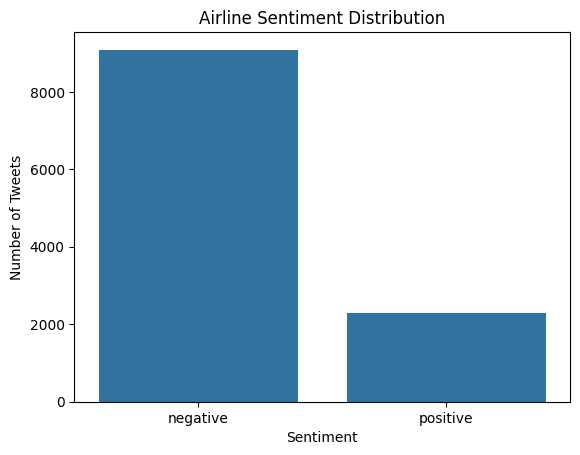

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    x='airline_sentiment',
    order=df['airline_sentiment'].value_counts().index
)
plt.title('Airline Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()

Displays the number of negative, neutral, and positive tweets and helps identify class imbalance.

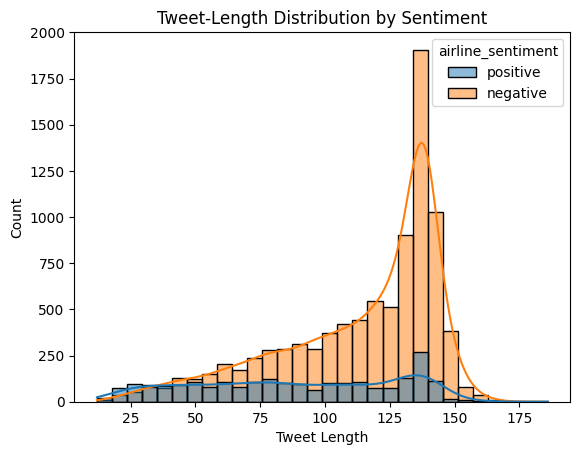

In [16]:
sns.histplot(
    data=df,
    x='tweet_length',
    hue='airline_sentiment',
    bins=30,
    kde=True
)
plt.title('Tweet-Length Distribution by Sentiment')
plt.xlabel('Tweet Length')
plt.show()

Compares the distribution of tweet lengths across the three sentiment classes.

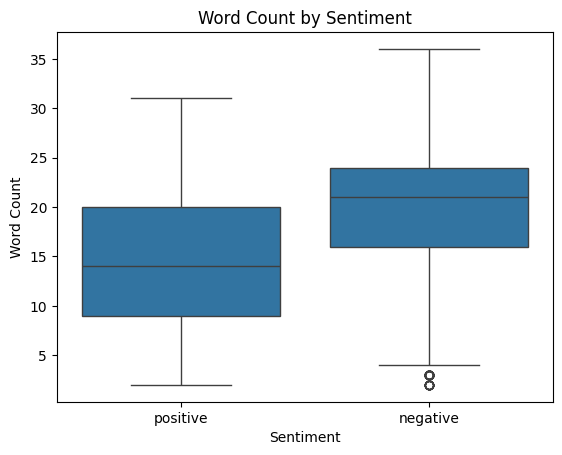

In [17]:
sns.boxplot(
    data=df,
    x='airline_sentiment',
    y='word_count'
)
plt.title('Word Count by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Word Count')
plt.show()

Compares the typical word count and possible word-count outliers for each sentiment category.

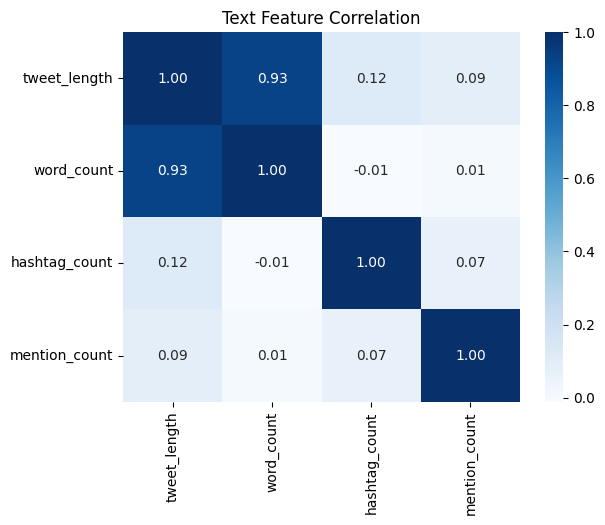

In [18]:
features = [
    'tweet_length',
    'word_count',
    'hashtag_count',
    'mention_count'
]

sns.heatmap(
    df[features].corr(),
    annot=True,
    cmap='Blues',
    fmt='.2f'
)
plt.title('Text Feature Correlation')
plt.show()

Shows relationships between the engineered numerical features, such as tweet length and word count.

In [19]:
counts = df['airline_sentiment'].value_counts()
avg_words = df.groupby('airline_sentiment')['word_count'].mean()
most_common = counts.idxmax()
longest_group = avg_words.idxmax()

print("### Key Insights"
print(f"1. After cleaning, the dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")
print(f"2. The most common sentiment is {most_common}, with {counts[most_common]} tweets.")
print(f"3. The average tweet contains {df['word_count'].mean():.1f} words.")
print(f"4. {longest_group.capitalize()} tweets have the highest average word count at {avg_words[longest_group]:.1f} words.")
print(f"5. The IQR analysis identified {len(outliers)} unusual tweet-length values, but they were retained because they are valid text observations.")

### Key Insights
1. After cleaning, the dataset contains 11385 rows and 6 columns.
2. The most common sentiment is negative, with 9087 tweets.
3. The average tweet contains 18.6 words.
4. Negative tweets have the highest average word count at 19.7 words.
5. The IQR analysis identified 0 unusual tweet-length values, but they were retained because they are valid text observations.


Produces five insights directly supported by the cleaning results, engineered features, and EDA analysis.

In [20]:
df = df[df['airline_sentiment'].isin(['positive', 'negative'])]


Neutral rows are removed because the pretrained pipeline provides only positive and negative predictions.

In [4]:
sample = df.sample(150, random_state=42).copy()

Randomly selects 150 tweets to make the evaluation faster. random_state=42 ensures that the same rows are selected each time.

In [5]:
sample['true_label'] = sample['airline_sentiment'].map({
    'positive': 'POSITIVE',
    'negative': 'NEGATIVE'
})

The required mapping is:

positive → POSITIVE
negative → NEGATIVE
neutral → excluded

Converts the dataset’s lowercase labels into the same uppercase format returned by the pretrained model, allowing direct comparison.

In [6]:
from transformers import pipeline

sentiment_model = pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

This downloads and loads a small pretrained sentiment model. No model training or GPU is required.

In [7]:
results = sentiment_model(
    sample['text'].tolist(),
    batch_size=16,
    truncation=True
)

sample['predicted_label'] = [result['label'] for result in results]

Converts the tweets into a list and sends them to the model for prediction. batch_size=16 processes 16 tweets at a time, while truncation=True safely shortens any text that exceeds the model’s maximum input length. The predicted labels are added to the sample DataFrame.

In [8]:
accuracy = (sample['true_label'] == sample['predicted_label']).mean()

print(f"Matching Fraction: {accuracy:.3f}")
print(f"Accuracy: {accuracy:.2%}")

Matching Fraction: 0.880
Accuracy: 88.00%


The matching fraction represents the proportion of transformer predictions that match the dataset labels.

The model correctly matched the dataset sentiment for 88% of the sampled positive and negative tweets. This is a strong result because the pretrained model was used directly without any training or fine-tuning on the airline dataset.

In [9]:
examples = sample[
    ['text', 'true_label', 'predicted_label']
].sample(5, random_state=42)

for _, row in examples.iterrows():
    print("Text:", row['text'])
    print("True Label:", row['true_label'])
    print("Predicted Label:", row['predicted_label'])
    print()

Text: @united your staff at LaGuardia and Lagos, Nigeria were unprofessional, uncaring and not helpful. Ou
True Label: NEGATIVE
Predicted Label: NEGATIVE

Text: @SouthwestAir Thx to customer service rep ALEX for his patient help in reFlight Booking Problems a Cancelled Flighted flight and getting us where we have to be tmrw!
True Label: POSITIVE
Predicted Label: NEGATIVE

Text: @SouthwestAir Thanks for two smooth, safe and fast flights! #Boston #Houston #LUVSWA http://t.co/elhxUV0Uj1
True Label: POSITIVE
Predicted Label: POSITIVE

Text: @SouthwestAir and currently as im bringing my 3 year old to the bathroom I'm being rushed by the flight attendant.
True Label: NEGATIVE
Predicted Label: NEGATIVE

Text: @united I'm rebooked on a flight tomorrow even though I had 1st class seat orig I have a lousy coach seat
True Label: NEGATIVE
Predicted Label: NEGATIVE



### Result Explanation

The pretrained Transformer achieved **88% accuracy**, correctly matching 132 out of 150 sampled tweets. In the five displayed examples, it correctly predicted four tweets and misclassified one positive tweet as negative, likely because it contained negative phrases such as “Cancelled Flight” and “reFlight Booking Problems.”

Attention allows the model to examine relationships between words and understand context across the sentence. Unlike Bag-of-Words, it considers word order and surrounding words instead of only counting how often each word appears.

Attention allows the transformer to consider how different words relate to one another across the entire sentence, including context and word order. Bag-of-Words only counts words and cannot understand these relationships—for example, the difference between “good” and “not good.”